# MorphPT cross-modal gene expression results

This notebook aggregates the four mouse Visium HD H&E-to-expression regression experiments.

The main aggregation unit is the spatial split layout, not the optimizer seed. The optimizer seed is fixed at 42. The five layouts per tissue use different held-out spatial tiles.

Recommended main panels:

A. Full 500-gene mean test Pearson r across five spatial split layouts.

B. Oracle performance-ranked gene-set size curve.

C to F. Variance-tier versus coverage-tier versus performance-tier curves for each tissue.

Spatial and per-tile plots are included as diagnostics and are better suited for supplementary material unless they reveal a clear failure mode.

## 1. Setup

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy.stats import wilcoxon
    HAS_SCIPY = True
except Exception:
    HAS_SCIPY = False
    warnings.warn("scipy is not available, Wilcoxon tests will be skipped.")

PROJECT = Path("/hpc/group/jilab/tc459/MorphPT")
OUT_DIR = PROJECT / "experiments" / "gene_expression_aggregate_figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)

TISSUES = ["mouse_brain", "mouse_intestine", "mouse_kidney", "mouse_embryo"]
LAYOUTS = ["seed23", "seed123", "seed456", "seed789", "seed1234"]
TIERS = [50, 100, 200, 300, 400, 500]

N_TOP = 500
SCALES_TAG = "10.0x"
LOSS_SUFFIX = "mse"
BASE_SEED = 42
SELECT_SEED = 42

TISSUE_COLORS = {
    "mouse_brain": "#4C72B0",
    "mouse_intestine": "#55A868",
    "mouse_kidney": "#C44E52",
    "mouse_embryo": "#8172B2",
}

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlelocation": "left",
    "axes.titleweight": "bold",
    "axes.titlesize": 11,
    "legend.frameon": False,
})

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 180)

print("Project:", PROJECT)
print("Output:", OUT_DIR)

Project: /hpc/group/jilab/tc459/MorphPT
Output: /hpc/group/jilab/tc459/MorphPT/experiments/gene_expression_aggregate_figures


## 2. Path helpers and column helpers

In [2]:
def clean_tissue_label(tissue):
    return str(tissue).replace("mouse_", "").replace("_", " ")

def results_dir(tissue, layout):
    return PROJECT / "experiments" / (
        f"lora_probing_{tissue}_top{N_TOP}_multi_{layout}_"
        f"{SCALES_TAG}_{LOSS_SUFFIX}_seed{BASE_SEED}"
    )

def results_csv(tissue, layout):
    return results_dir(tissue, layout) / "multi_lora_hybrid_results.csv"

def rank_csv(tissue, layout):
    return (
        PROJECT / f"cache_{tissue}" / "splits" / layout /
        f"top{N_TOP}_variance_mincov0.1_train_{layout}_seed{SELECT_SEED}.csv"
    )

def savefig(name):
    png = OUT_DIR / f"{name}.png"
    pdf = OUT_DIR / f"{name}.pdf"
    plt.savefig(png, bbox_inches="tight")
    plt.savefig(pdf, bbox_inches="tight")
    print("Saved:")
    print(png)
    print(pdf)

def first_existing(columns, candidates):
    for c in candidates:
        if c in columns:
            return c
    return None

def pick_metric_column(df, prefix, seed=BASE_SEED):
    preferred = [
        f"{prefix}_s{seed}",
        f"{prefix}_seed{seed}",
        prefix,
    ]
    for c in preferred:
        if c in df.columns:
            return c
    matches = [c for c in df.columns if c.startswith(prefix)]
    if matches:
        return matches[0]
    raise ValueError(f"Could not find a column starting with {prefix}. Available columns: {list(df.columns)}")

def require_columns(df, cols, name):
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"{name} is missing columns {missing}. Found columns: {list(df.columns)}")

## 3. Load result CSVs and gene-ranking files

This cell joins each per-gene result file with the layout-specific gene-ranking file.

Important change from the previous notebook: it loads both the variance rank and the coverage value. Coverage rank is computed within each layout as descending coverage, so top-50 coverage means the 50 most broadly detected genes in the training set.

In [3]:
rows = []
missing = []

for tissue in TISSUES:
    for layout in LAYOUTS:
        rcsv = results_csv(tissue, layout)
        kcsv = rank_csv(tissue, layout)

        if not rcsv.exists():
            missing.append((tissue, layout, "result", str(rcsv)))
            continue
        if not kcsv.exists():
            missing.append((tissue, layout, "ranking", str(kcsv)))
            continue

        res = pd.read_csv(rcsv)
        ranks = pd.read_csv(kcsv)

        # Normalize likely column variants.
        if "rank" not in ranks.columns:
            alt_rank = first_existing(ranks.columns, ["variance_rank", "var_rank"])
            if alt_rank is None:
                raise ValueError(f"{kcsv} does not contain rank or variance_rank. Columns: {list(ranks.columns)}")
            ranks = ranks.rename(columns={alt_rank: "rank"})

        keep_cols = ["gene_idx", "rank"]
        if "gene_name" in ranks.columns:
            keep_cols.append("gene_name")
        if "coverage" in ranks.columns:
            keep_cols.append("coverage")

        ranks = ranks[keep_cols].copy()
        ranks["variance_rank"] = pd.to_numeric(ranks["rank"], errors="coerce")

        if "coverage" in ranks.columns:
            ranks["coverage_rank"] = (
                ranks["coverage"]
                .rank(method="first", ascending=False)
                .astype(int)
            )
        else:
            ranks["coverage"] = np.nan
            ranks["coverage_rank"] = np.nan

        merged = res.merge(
            ranks.drop(columns=["rank"]),
            on="gene_idx",
            how="left",
            suffixes=("", "_rankfile"),
        )

        # Prefer result gene_name if present, otherwise ranking-file gene_name.
        if "gene_name" not in merged.columns and "gene_name_rankfile" in merged.columns:
            merged["gene_name"] = merged["gene_name_rankfile"]
        elif "gene_name" in merged.columns and "gene_name_rankfile" in merged.columns:
            merged["gene_name"] = merged["gene_name"].fillna(merged["gene_name_rankfile"])

        test_col = pick_metric_column(merged, "test_pearson")
        val_col = pick_metric_column(merged, "val_pearson")

        for _, r in merged.iterrows():
            rows.append({
                "tissue": tissue,
                "layout": layout,
                "gene_idx": int(r["gene_idx"]),
                "gene_name": r["gene_name"] if "gene_name" in merged.columns else str(r["gene_idx"]),
                "variance_rank": int(r["variance_rank"]) if pd.notna(r["variance_rank"]) else np.nan,
                "coverage": float(r["coverage"]) if pd.notna(r["coverage"]) else np.nan,
                "coverage_rank": int(r["coverage_rank"]) if pd.notna(r["coverage_rank"]) else np.nan,
                "test_pearson": float(r[test_col]),
                "val_pearson": float(r[val_col]),
                "result_csv": str(rcsv),
                "rank_csv": str(kcsv),
            })

df = pd.DataFrame(rows)

if df.empty:
    raise RuntimeError("No rows loaded. Check PROJECT, folder names, and file names.")

print(f"Loaded {len(df):,} gene rows from {df.groupby(['tissue', 'layout']).ngroups} tissue-layout runs.")

if missing:
    print(f"\nMissing files ({len(missing)}):")
    for m in missing:
        print("  ", m)

df.to_csv(OUT_DIR / "mouse_gene_expression_long_results.csv", index=False)
display(df.head())

Loaded 10,000 gene rows from 20 tissue-layout runs.


,tissue,layout,gene_idx,gene_name,variance_rank,coverage,coverage_rank,test_pearson,val_pearson,result_csv,rank_csv
0,mouse_brain,seed23,1401,Nrgn,1,0.587008,64,0.515073,0.541119,/hpc/group/jilab/tc459/MorphPT/experiments/lora_probing_mouse_brain_top500_multi_seed23_10.0x_mse_seed42/multi_lora_hybrid_results.csv,/hpc/group/jilab/tc459/MorphPT/cache_mouse_brain/splits/seed23/top500_variance_mincov0.1_train_seed23_seed42.csv
1,mouse_brain,seed23,675,Camk2n1,2,0.824344,8,0.427236,0.183017,/hpc/group/jilab/tc459/MorphPT/experiments/lora_probing_mouse_brain_top500_multi_seed23_10.0x_mse_seed42/multi_lora_hybrid_results.csv,/hpc/group/jilab/tc459/MorphPT/cache_mouse_brain/splits/seed23/top500_variance_mincov0.1_train_seed23_seed42.csv
2,mouse_brain,seed23,2435,Pcp4,3,0.429619,167,0.387579,0.679604,/hpc/group/jilab/tc459/MorphPT/experiments/lora_probing_mouse_brain_top500_multi_seed23_10.0x_mse_seed42/multi_lora_hybrid_results.csv,/hpc/group/jilab/tc459/MorphPT/cache_mouse_brain/splits/seed23/top500_variance_mincov0.1_train_seed23_seed42.csv
3,mouse_brain,seed23,1076,Apoe,4,0.613930,49,0.451317,0.343422,/hpc/group/jilab/tc459/MorphPT/experiments/lora_probing_mouse_brain_top500_multi_seed23_10.0x_mse_seed42/multi_lora_hybrid_results.csv,/hpc/group/jilab/tc459/MorphPT/cache_mouse_brain/splits/seed23/top500_variance_mincov0.1_train_seed23_seed42.csv
4,mouse_brain,seed23,221,Olfm1,5,0.699344,23,0.336494,0.410355,/hpc/group/jilab/tc459/MorphPT/experiments/lora_probing_mouse_brain_top500_multi_seed23_10.0x_mse_seed42/multi_lora_hybrid_results.csv,/hpc/group/jilab/tc459/MorphPT/cache_mouse_brain/splits/seed23/top500_variance_mincov0.1_train_seed23_seed42.csv


## 4. Sanity checks

In [4]:
run_check = (
    df.groupby(["tissue", "layout"], dropna=False)
      .agg(
          n_genes=("gene_idx", "count"),
          n_unique_genes=("gene_idx", "nunique"),
          missing_variance_rank=("variance_rank", lambda x: x.isna().sum()),
          missing_coverage=("coverage", lambda x: x.isna().sum()),
          mean_test_r=("test_pearson", "mean"),
          median_test_r=("test_pearson", "median"),
      )
      .reset_index()
      .sort_values(["tissue", "layout"])
)

display(run_check)

expected_runs = len(TISSUES) * len(LAYOUTS)
loaded_runs = run_check.shape[0]

print(f"Expected runs: {expected_runs}")
print(f"Loaded runs:   {loaded_runs}")

bad_gene_counts = run_check[run_check["n_genes"] != N_TOP]
if not bad_gene_counts.empty:
    print("\nRuns with unexpected gene counts:")
    display(bad_gene_counts)

coverage_available = df["coverage"].notna().any()
print("Coverage ranking available:", coverage_available)

,tissue,layout,n_genes,n_unique_genes,missing_variance_rank,missing_coverage,mean_test_r,median_test_r
0,mouse_brain,seed123,500,500,0,0,0.277280,0.257543
1,mouse_brain,seed1234,500,500,0,0,0.214821,0.200909
2,mouse_brain,seed23,500,500,0,0,0.214539,0.200041
3,mouse_brain,seed456,500,500,0,0,0.281085,0.259897
4,mouse_brain,seed789,500,500,0,0,0.277861,0.270368
5,mouse_embryo,seed123,500,500,0,0,0.243368,0.190850
6,mouse_embryo,seed1234,500,500,0,0,0.136262,0.116916
7,mouse_embryo,seed23,500,500,0,0,0.229956,0.185523
8,mouse_embryo,seed456,500,500,0,0,0.247118,0.196917
9,mouse_embryo,seed789,500,500,0,0,0.162825,0.136650


Expected runs: 20
Loaded runs:   20
Coverage ranking available: True


## 5. Full 500-gene performance across spatial layouts

In [5]:
per_run = (
    df.groupby(["tissue", "layout"], dropna=False)
      .agg(
          mean_test_r=("test_pearson", "mean"),
          median_test_r=("test_pearson", "median"),
          n_genes=("gene_idx", "count"),
      )
      .reset_index()
)

pivot = per_run.pivot(index="tissue", columns="layout", values="mean_test_r").reindex(TISSUES)
for layout in LAYOUTS:
    if layout not in pivot.columns:
        pivot[layout] = np.nan
pivot = pivot[LAYOUTS]
pivot["mean"] = pivot[LAYOUTS].mean(axis=1)
pivot["std"] = pivot[LAYOUTS].std(axis=1, ddof=1)

display(pivot.round(4))

per_run.to_csv(OUT_DIR / "per_run_500_gene_summary.csv", index=False)
pivot.to_csv(OUT_DIR / "per_tissue_500_gene_pivot.csv")

layout,seed23,seed123,seed456,seed789,seed1234,mean,std
tissue,,,,,,,
mouse_brain,0.2145,0.2773,0.2811,0.2779,0.2148,0.2531,0.0351
mouse_intestine,0.2852,0.2633,0.2762,0.2614,0.2617,0.2696,0.0107
mouse_kidney,0.3048,0.3156,0.3230,0.3517,0.3320,0.3254,0.0178
mouse_embryo,0.2300,0.2434,0.2471,0.1628,0.1363,0.2039,0.0509


## 6. Panel A, full 500-gene mean test Pearson

Saved:
/hpc/group/jilab/tc459/MorphPT/experiments/gene_expression_aggregate_figures/panel_a_full_500_gene_performance.png
/hpc/group/jilab/tc459/MorphPT/experiments/gene_expression_aggregate_figures/panel_a_full_500_gene_performance.pdf


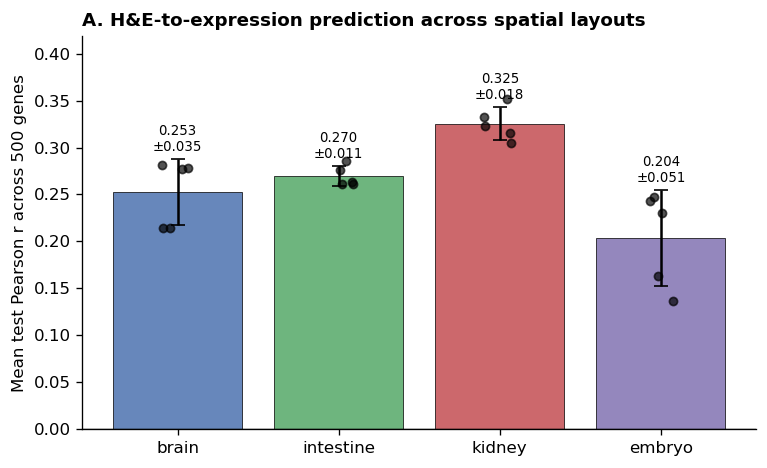

In [6]:
agg500 = (
    per_run.groupby("tissue")["mean_test_r"]
           .agg(mean="mean", std=lambda x: x.std(ddof=1), n="count", values=list)
           .reindex(TISSUES)
)

fig, ax = plt.subplots(figsize=(6.5, 4.0))
xs = np.arange(len(agg500))

ax.bar(
    xs,
    agg500["mean"],
    yerr=agg500["std"],
    capsize=4,
    color=[TISSUE_COLORS[t] for t in agg500.index],
    edgecolor="black",
    linewidth=0.5,
    alpha=0.85,
)

rng = np.random.default_rng(0)
for i, (_, row) in enumerate(agg500.iterrows()):
    vals = np.asarray(row["values"], dtype=float)
    xj = i + rng.uniform(-0.10, 0.10, len(vals))
    ax.scatter(xj, vals, s=24, color="black", alpha=0.68, zorder=3)

for i, (mean, std) in enumerate(zip(agg500["mean"], agg500["std"])):
    ax.text(i, mean + std + 0.005, f"{mean:.3f}\n±{std:.3f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(xs)
ax.set_xticklabels([clean_tissue_label(t) for t in agg500.index])
ax.set_ylabel("Mean test Pearson r across 500 genes")
ax.set_title("A. H&E-to-expression prediction across spatial layouts")
ax.axhline(0, linewidth=0.8, color="black")
ax.set_ylim(0, max(agg500["mean"] + agg500["std"]) * 1.22)

plt.tight_layout()
savefig("panel_a_full_500_gene_performance")
plt.show()

## 7. Tier analysis helpers

In [7]:
def make_tier_df_from_rank(df, rank_col, label):
    require_columns(df, ["tissue", "layout", rank_col, "test_pearson"], f"{label} input df")
    tier_rows = []

    for tissue in TISSUES:
        for layout in LAYOUTS:
            sub = df[(df["tissue"] == tissue) & (df["layout"] == layout)].copy()
            if sub.empty:
                continue

            for tier in TIERS:
                top_n = sub[sub[rank_col] <= tier]
                tier_rows.append({
                    "ranking": label,
                    "tissue": tissue,
                    "layout": layout,
                    "tier": tier,
                    "mean_test_r": top_n["test_pearson"].mean(),
                    "n_genes": len(top_n),
                })

    return pd.DataFrame(tier_rows)

def make_performance_tier_df(df):
    tier_rows = []

    for tissue in TISSUES:
        for layout in LAYOUTS:
            sub = df[(df["tissue"] == tissue) & (df["layout"] == layout)].copy()
            if sub.empty:
                continue

            sub = sub.sort_values("test_pearson", ascending=False)

            for tier in TIERS:
                top_n = sub.head(tier)
                tier_rows.append({
                    "ranking": "performance",
                    "tissue": tissue,
                    "layout": layout,
                    "tier": tier,
                    "mean_test_r": top_n["test_pearson"].mean(),
                    "n_genes": len(top_n),
                })

    return pd.DataFrame(tier_rows)

def aggregate_tiers(tier_df):
    return (
        tier_df.groupby(["ranking", "tissue", "tier"], dropna=False)
               .agg(
                   mean=("mean_test_r", "mean"),
                   std=("mean_test_r", lambda x: x.std(ddof=1)),
                   n_layouts=("layout", "nunique"),
               )
               .reset_index()
               .sort_values(["ranking", "tissue", "tier"])
    )

## 8. Compute variance, coverage, and performance tiers

Variance and coverage are a-priori rankings computed from training cells. Performance ranking is post-hoc and should be treated as an oracle ceiling.

In [8]:
var_tier_df = make_tier_df_from_rank(df, "variance_rank", "variance")

if df["coverage_rank"].notna().any():
    cov_tier_df = make_tier_df_from_rank(df, "coverage_rank", "coverage")
else:
    cov_tier_df = pd.DataFrame()
    print("Coverage ranking is unavailable because the ranking CSVs do not contain coverage.")

perf_tier_df = make_performance_tier_df(df)

tier_all = pd.concat(
    [x for x in [var_tier_df, cov_tier_df, perf_tier_df] if not x.empty],
    ignore_index=True,
)

tier_agg = aggregate_tiers(tier_all)

display(tier_agg.head(20))

tier_all.to_csv(OUT_DIR / "tier_results_by_layout.csv", index=False)
tier_agg.to_csv(OUT_DIR / "tier_results_aggregated.csv", index=False)

for ranking in tier_agg["ranking"].unique():
    print(f"\n{ranking} tier means:")
    display(
        tier_agg[tier_agg["ranking"] == ranking]
        .pivot(index="tier", columns="tissue", values="mean")
        .reindex(index=TIERS, columns=TISSUES)
        .round(3)
    )

,ranking,tissue,tier,mean,std,n_layouts
0,coverage,mouse_brain,50,0.331408,0.035676,5
1,coverage,mouse_brain,100,0.310172,0.037614,5
2,coverage,mouse_brain,200,0.287427,0.033988,5
3,coverage,mouse_brain,300,0.271941,0.037028,5
4,coverage,mouse_brain,400,0.261428,0.037615,5
5,coverage,mouse_brain,500,0.253117,0.035118,5
6,coverage,mouse_embryo,50,0.318554,0.089992,5
7,coverage,mouse_embryo,100,0.277448,0.067504,5
8,coverage,mouse_embryo,200,0.235286,0.056484,5
9,coverage,mouse_embryo,300,0.214279,0.051589,5



coverage tier means:


tissue,mouse_brain,mouse_intestine,mouse_kidney,mouse_embryo
tier,,,,
50,0.331,0.511,0.535,0.319
100,0.310,0.440,0.478,0.277
200,0.287,0.361,0.407,0.235
300,0.272,0.315,0.372,0.214
400,0.261,0.288,0.342,0.201
500,0.253,0.270,0.325,0.204



performance tier means:


tissue,mouse_brain,mouse_intestine,mouse_kidney,mouse_embryo
tier,,,,
50,0.446,0.672,0.734,0.499
100,0.395,0.571,0.657,0.404
200,0.340,0.445,0.537,0.314
300,0.306,0.367,0.446,0.265
400,0.279,0.314,0.379,0.231
500,0.253,0.270,0.325,0.204



variance tier means:


tissue,mouse_brain,mouse_intestine,mouse_kidney,mouse_embryo
tier,,,,
50,0.355,0.578,0.615,0.355
100,0.326,0.470,0.524,0.290
200,0.293,0.385,0.438,0.249
300,0.276,0.337,0.390,0.229
400,0.265,0.297,0.355,0.214
500,0.253,0.270,0.325,0.204


## 9. Panel B, oracle performance-ranked gene-set size curve

Saved:
/hpc/group/jilab/tc459/MorphPT/experiments/gene_expression_aggregate_figures/panel_b_performance_ranked_curve.png
/hpc/group/jilab/tc459/MorphPT/experiments/gene_expression_aggregate_figures/panel_b_performance_ranked_curve.pdf


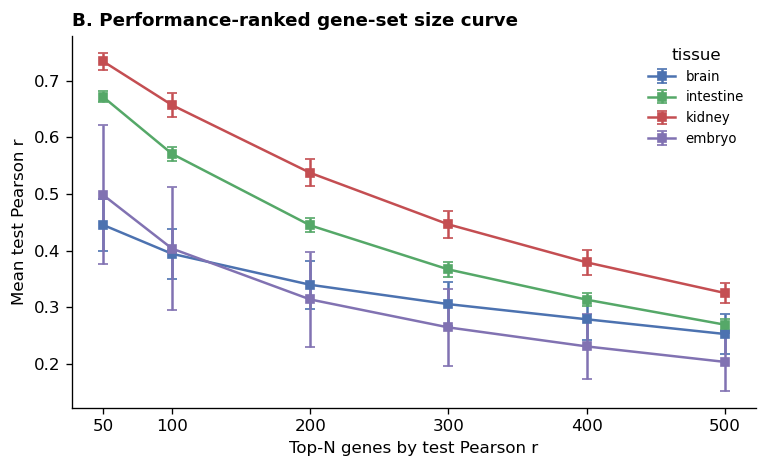

In [10]:
perf_agg = tier_agg[tier_agg["ranking"] == "performance"].copy()

fig, ax = plt.subplots(figsize=(6.5, 4.0))

for tissue in TISSUES:
    sub = perf_agg[perf_agg["tissue"] == tissue].sort_values("tier")
    ax.errorbar(
        sub["tier"],
        sub["mean"],
        yerr=sub["std"],
        marker="s",
        markersize=5,
        capsize=3,
        linewidth=1.5,
        color=TISSUE_COLORS[tissue],
        label=clean_tissue_label(tissue),
    )

ax.set_xlabel("Top-N genes by test Pearson r")
ax.set_ylabel("Mean test Pearson r")
ax.set_title("B. Performance-ranked gene-set size curve")
ax.set_xticks(TIERS)
ax.legend(title="tissue", fontsize=8)
plt.tight_layout()
savefig("panel_b_performance_ranked_curve")
plt.show()

## 10. Panel C, variance-tier versus coverage-tier versus performance-tier

Saved:
/hpc/group/jilab/tc459/MorphPT/experiments/gene_expression_aggregate_figures/panel_c_variance_coverage_performance_tiers.png
/hpc/group/jilab/tc459/MorphPT/experiments/gene_expression_aggregate_figures/panel_c_variance_coverage_performance_tiers.pdf


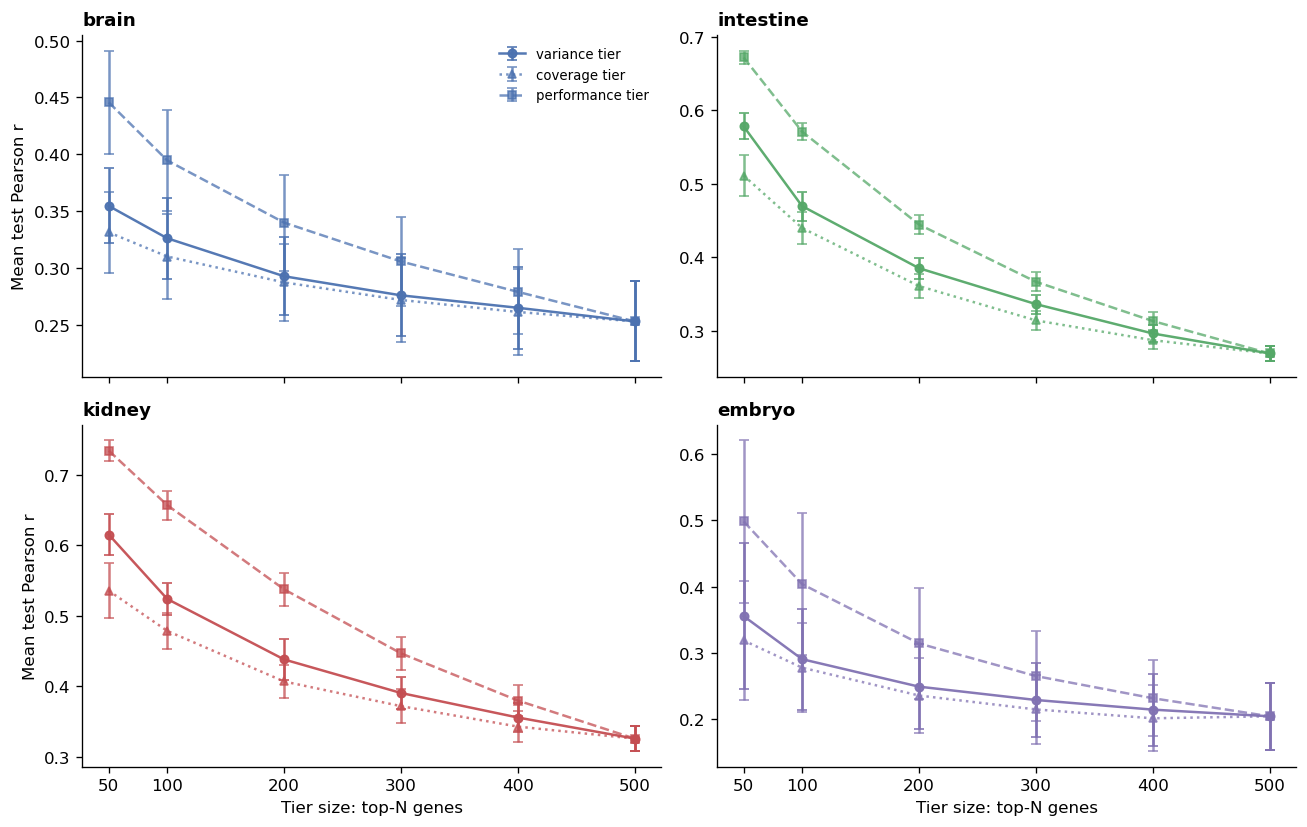

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)

styles = {
    "variance": dict(marker="o", linestyle="-", label="variance tier"),
    "coverage": dict(marker="^", linestyle=":", label="coverage tier"),
    "performance": dict(marker="s", linestyle="--", label="performance tier"),
}

for i, (ax, tissue) in enumerate(zip(axes.flat, TISSUES)):
    color = TISSUE_COLORS[tissue]

    for ranking in ["variance", "coverage", "performance"]:
        sub = tier_agg[(tier_agg["ranking"] == ranking) & (tier_agg["tissue"] == tissue)].sort_values("tier")
        if sub.empty:
            continue

        alpha = 0.95 if ranking == "variance" else 0.75
        ax.errorbar(
            sub["tier"],
            sub["mean"],
            yerr=sub["std"],
            markersize=5,
            capsize=3,
            linewidth=1.5,
            color=color,
            alpha=alpha,
            **styles[ranking],
        )

    ax.set_title(clean_tissue_label(tissue))
    ax.set_xticks(TIERS)

    if i == 0:
        ax.legend(loc="best", fontsize=8)

for ax in axes[-1, :]:
    ax.set_xlabel("Tier size: top-N genes")
for ax in axes[:, 0]:
    ax.set_ylabel("Mean test Pearson r")

plt.tight_layout()
savefig("panel_c_variance_coverage_performance_tiers")
plt.show()

## 11. Variance versus coverage gap statistics

In [12]:
if cov_tier_df.empty:
    print("Coverage tiers are unavailable, skipping gap statistics.")
else:
    var_agg = tier_agg[tier_agg["ranking"] == "variance"]
    cov_agg = tier_agg[tier_agg["ranking"] == "coverage"]

    gap = var_agg.merge(
        cov_agg,
        on=["tissue", "tier"],
        suffixes=("_var", "_cov"),
    )
    gap["delta"] = gap["mean_var"] - gap["mean_cov"]

    gap_pivot = gap.pivot(index="tier", columns="tissue", values="delta").reindex(index=TIERS, columns=TISSUES)
    gap_summary = gap.groupby("tier")["delta"].agg(["mean", "std", "min", "max"]).reindex(TIERS)

    print("Variance minus coverage gap:")
    display(gap_pivot.round(4))

    print("Mean variance-over-coverage gap per tier:")
    display(gap_summary.round(4))

    gap_pivot.to_csv(OUT_DIR / "variance_minus_coverage_gap_by_tissue_tier.csv")
    gap_summary.to_csv(OUT_DIR / "variance_minus_coverage_gap_summary.csv")

    paired = (
        var_tier_df.rename(columns={"mean_test_r": "var_r"})
        .merge(
            cov_tier_df.rename(columns={"mean_test_r": "cov_r"}),
            on=["tissue", "layout", "tier"],
            suffixes=("", "_cov"),
        )
    )
    paired = paired[paired["tier"] != 500].copy()
    paired["delta"] = paired["var_r"] - paired["cov_r"]

    print(f"Variance beats coverage in {(paired['delta'] > 0).sum()}/{len(paired)} raw tissue-layout-tier pairs.")

    if HAS_SCIPY:
        stat, p = wilcoxon(paired["delta"], alternative="greater")
        print("Raw paired Wilcoxon, descriptive because tiers are nested:")
        print(f"  n={len(paired)}, W={stat:.0f}, p={p:.2e}")

        collapsed = (
            paired.groupby(["tissue", "layout"], dropna=False)["delta"]
                  .mean()
                  .reset_index()
        )
        stat2, p2 = wilcoxon(collapsed["delta"], alternative="greater")
        print("Collapsed tissue-layout Wilcoxon, preferred for the paper:")
        print(f"  n={len(collapsed)}, W={stat2:.0f}, p={p2:.2e}")
        print(f"  positive mean gap in {(collapsed['delta'] > 0).sum()}/{len(collapsed)} tissue-layouts")

        collapsed.to_csv(OUT_DIR / "variance_coverage_collapsed_tissue_layout_gaps.csv", index=False)

    flipped = paired[paired["delta"] < 0].copy()
    if not flipped.empty:
        print("Cases where coverage beats variance:")
        display(flipped[["tissue", "layout", "tier", "var_r", "cov_r", "delta"]].sort_values("delta").round(4))

Variance minus coverage gap:


tissue,mouse_brain,mouse_intestine,mouse_kidney,mouse_embryo
tier,,,,
50,0.0232,0.0668,0.0797,0.0369
100,0.0160,0.0297,0.0453,0.0128
200,0.0054,0.0242,0.0313,0.0134
300,0.0041,0.0221,0.0187,0.0143
400,0.0037,0.0091,0.0129,0.0131
500,0.0000,0.0000,0.0000,0.0000


Mean variance-over-coverage gap per tier:


,mean,std,min,max
tier,,,,
50,0.0516,0.0261,0.0232,0.0797
100,0.0260,0.0148,0.0128,0.0453
200,0.0186,0.0115,0.0054,0.0313
300,0.0148,0.0078,0.0041,0.0221
400,0.0097,0.0044,0.0037,0.0131
500,0.0000,0.0000,0.0000,0.0000


Variance beats coverage in 98/100 raw tissue-layout-tier pairs.
Raw paired Wilcoxon, descriptive because tiers are nested:
  n=100, W=5046, p=2.20e-18
Collapsed tissue-layout Wilcoxon, preferred for the paper:
  n=20, W=210, p=9.54e-07
  positive mean gap in 20/20 tissue-layouts
Cases where coverage beats variance:


,tissue,layout,tier,var_r,cov_r,delta
22,mouse_brain,seed789,400,0.2889,0.2891,-0.0003
21,mouse_brain,seed789,300,0.2996,0.2997,-0.0001


## 12. Top-50 variance versus coverage overlap

In [13]:
if "coverage_rank" not in df.columns or not df["coverage_rank"].notna().any():
    print("Coverage rank unavailable.")
else:
    overlap_rows = []
    for tissue in TISSUES:
        for layout in LAYOUTS:
            sub = df[(df["tissue"] == tissue) & (df["layout"] == layout)]
            top_var = set(sub.loc[sub["variance_rank"] <= 50, "gene_name"])
            top_cov = set(sub.loc[sub["coverage_rank"] <= 50, "gene_name"])
            overlap_rows.append({
                "tissue": tissue,
                "layout": layout,
                "overlap_n": len(top_var & top_cov),
                "overlap_frac": len(top_var & top_cov) / 50,
                "coverage_only_examples": ", ".join(sorted(list(top_cov - top_var))[:8]),
            })

    overlap = pd.DataFrame(overlap_rows)
    display(overlap)

    overlap_summary = (
        overlap.groupby("tissue")
               .agg(mean_overlap=("overlap_n", "mean"), std_overlap=("overlap_n", lambda x: x.std(ddof=1)))
               .reindex(TISSUES)
    )
    display(overlap_summary.round(2))

    overlap.to_csv(OUT_DIR / "top50_variance_coverage_overlap_by_layout.csv", index=False)
    overlap_summary.to_csv(OUT_DIR / "top50_variance_coverage_overlap_summary.csv")

,tissue,layout,overlap_n,overlap_frac,coverage_only_examples
0,mouse_brain,seed23,31,0.62,"App, Atp6v0a1, Calm3, Dynll2, Eef1a2, Ptms, Rab3a, Selenow"
1,mouse_brain,seed123,33,0.66,"App, Atp6v0a1, Calm3, Dynll2, Mdh1, Ptms, Rab3a, Selenow"
2,mouse_brain,seed456,33,0.66,"App, Atp6v0a1, Calm3, Eef1a2, Ptms, Rab3a, Selenow, Serinc1"
3,mouse_brain,seed789,34,0.68,"App, Atp6v0a1, Calm3, Dynll2, Mdh1, Rab3a, Rab6b, Selenow"
4,mouse_brain,seed1234,32,0.64,"App, Atp6v0a1, Calm3, Dynll2, Eef1a2, Ptms, Rab3a, Selenow"
5,mouse_intestine,seed23,39,0.78,"Akr1a1, Anxa4, Cd74, Cldn7, Epcam, Krt8, Lgals4, Muc13"
6,mouse_intestine,seed123,40,0.80,"Akr1a1, Anxa4, Cd74, Cldn7, Krt8, Lgals4, Muc13, Spint2"
7,mouse_intestine,seed456,39,0.78,"Akr1a1, Cd74, Cldn7, Epcam, Krt8, Lgals4, Muc13, Phgr1"
8,mouse_intestine,seed789,39,0.78,"Akr1a1, Cd74, Cldn7, Epcam, Fth1, Krt8, Lgals4, Muc13"
9,mouse_intestine,seed1234,39,0.78,"Akr1a1, Cd74, Cldn7, Epcam, Krt8, Lgals4, Muc13, Spint2"


,mean_overlap,std_overlap
tissue,,
mouse_brain,32.6,1.14
mouse_intestine,39.2,0.45
mouse_kidney,35.4,1.14
mouse_embryo,40.0,1.87


## 13. Composite paper figure candidate

This makes one multi-panel figure:

A. Full 500-gene performance.

B. Performance-ranked oracle curve.

C to F. Variance, coverage, and performance tier curves for each tissue.

Use this as the main figure if space allows. Otherwise use A and C to F in the main figure and move B to supplement.

Saved:
/hpc/group/jilab/tc459/MorphPT/experiments/gene_expression_aggregate_figures/paper_composite_gene_expression_results.png
/hpc/group/jilab/tc459/MorphPT/experiments/gene_expression_aggregate_figures/paper_composite_gene_expression_results.pdf


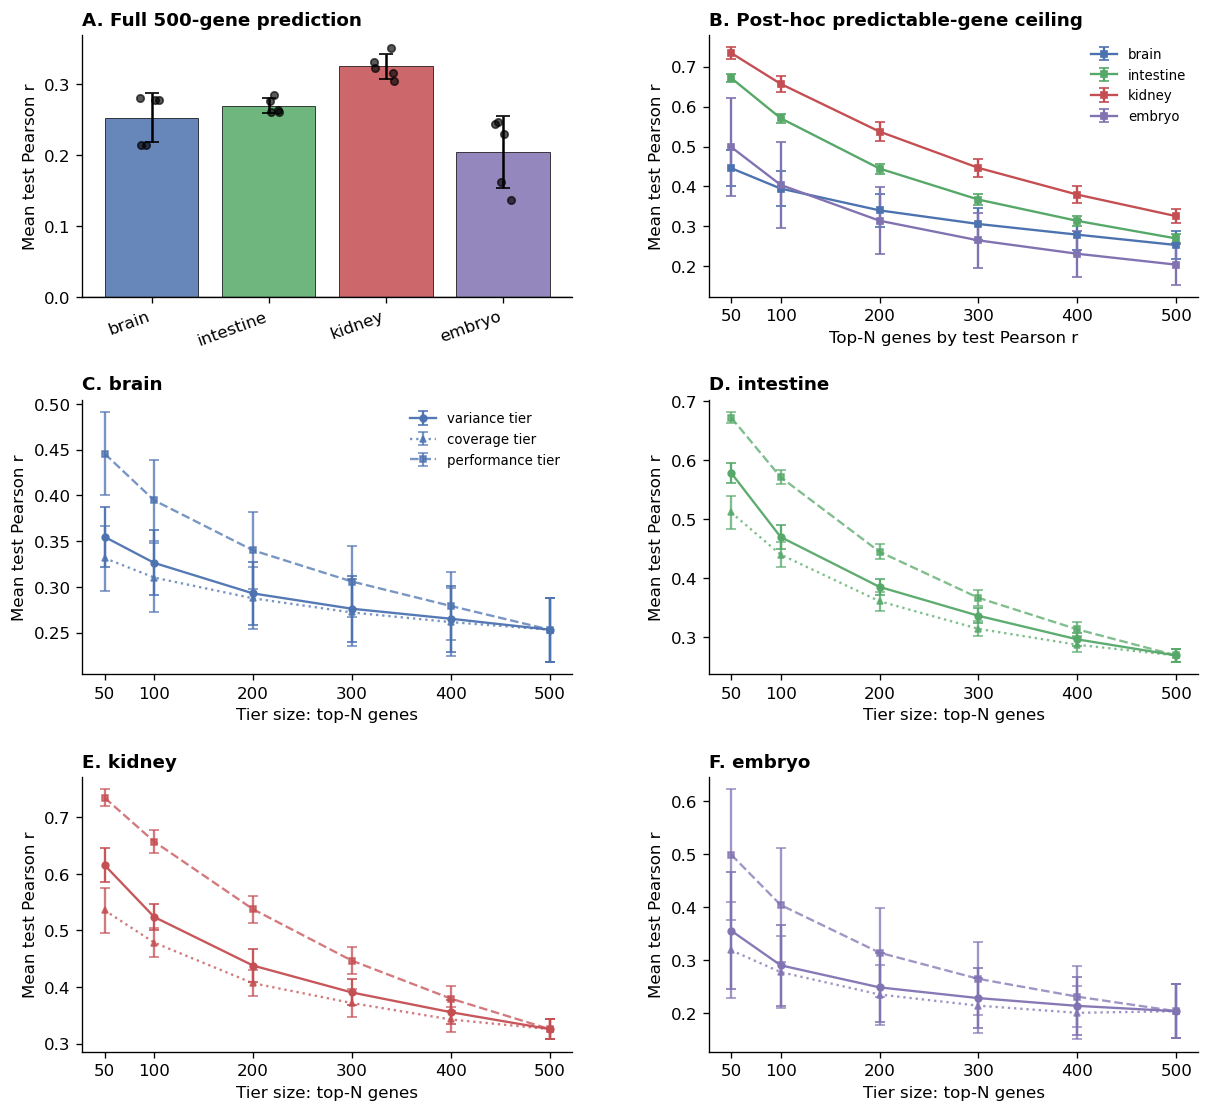

In [14]:
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(12, 11))
gs = GridSpec(3, 2, figure=fig, height_ratios=[1.0, 1.05, 1.05], hspace=0.38, wspace=0.28)

# Panel A
ax_a = fig.add_subplot(gs[0, 0])
xs = np.arange(len(agg500))
ax_a.bar(
    xs,
    agg500["mean"],
    yerr=agg500["std"],
    capsize=4,
    color=[TISSUE_COLORS[t] for t in agg500.index],
    edgecolor="black",
    linewidth=0.5,
    alpha=0.85,
)
rng = np.random.default_rng(0)
for i, (_, row) in enumerate(agg500.iterrows()):
    vals = np.asarray(row["values"], dtype=float)
    ax_a.scatter(i + rng.uniform(-0.10, 0.10, len(vals)), vals, s=20, color="black", alpha=0.65, zorder=3)
ax_a.set_xticks(xs)
ax_a.set_xticklabels([clean_tissue_label(t) for t in agg500.index], rotation=20, ha="right")
ax_a.set_ylabel("Mean test Pearson r")
ax_a.set_title("A. Full 500-gene prediction")
ax_a.axhline(0, linewidth=0.8, color="black")

# Panel B
ax_b = fig.add_subplot(gs[0, 1])
for tissue in TISSUES:
    sub = perf_agg[perf_agg["tissue"] == tissue].sort_values("tier")
    ax_b.errorbar(
        sub["tier"],
        sub["mean"],
        yerr=sub["std"],
        marker="s",
        markersize=4,
        capsize=3,
        linewidth=1.4,
        color=TISSUE_COLORS[tissue],
        label=clean_tissue_label(tissue),
    )
ax_b.set_xlabel("Top-N genes by test Pearson r")
ax_b.set_ylabel("Mean test Pearson r")
ax_b.set_title("B. Post-hoc predictable-gene ceiling")
ax_b.set_xticks(TIERS)
ax_b.legend(fontsize=8)

# Panels C to F
tier_axes = [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1]), fig.add_subplot(gs[2, 0]), fig.add_subplot(gs[2, 1])]
panel_letters = ["C", "D", "E", "F"]

for i, (ax, tissue, letter) in enumerate(zip(tier_axes, TISSUES, panel_letters)):
    color = TISSUE_COLORS[tissue]

    for ranking in ["variance", "coverage", "performance"]:
        sub = tier_agg[(tier_agg["ranking"] == ranking) & (tier_agg["tissue"] == tissue)].sort_values("tier")
        if sub.empty:
            continue

        alpha = 0.95 if ranking == "variance" else 0.75
        ax.errorbar(
            sub["tier"],
            sub["mean"],
            yerr=sub["std"],
            markersize=4,
            capsize=3,
            linewidth=1.4,
            color=color,
            alpha=alpha,
            **styles[ranking],
        )

    ax.set_title(f"{letter}. {clean_tissue_label(tissue)}")
    ax.set_xticks(TIERS)
    ax.set_xlabel("Tier size: top-N genes")
    ax.set_ylabel("Mean test Pearson r")
    if i == 0:
        ax.legend(loc="best", fontsize=8)

savefig("paper_composite_gene_expression_results")
plt.show()

## 14. Best layout per tissue, diagnostic only

,tissue,best_layout,best_mean_r,median_test_r,worst_layout,worst_mean_r,range
0,mouse_brain,seed456,0.2811,0.2599,seed23,0.2145,0.0665
1,mouse_intestine,seed23,0.2852,0.2348,seed789,0.2614,0.0238
2,mouse_kidney,seed789,0.3517,0.2919,seed23,0.3048,0.0469
3,mouse_embryo,seed456,0.2471,0.1969,seed1234,0.1363,0.1109


Saved:
/hpc/group/jilab/tc459/MorphPT/experiments/gene_expression_aggregate_figures/diagnostic_best_layout_spread.png
/hpc/group/jilab/tc459/MorphPT/experiments/gene_expression_aggregate_figures/diagnostic_best_layout_spread.pdf


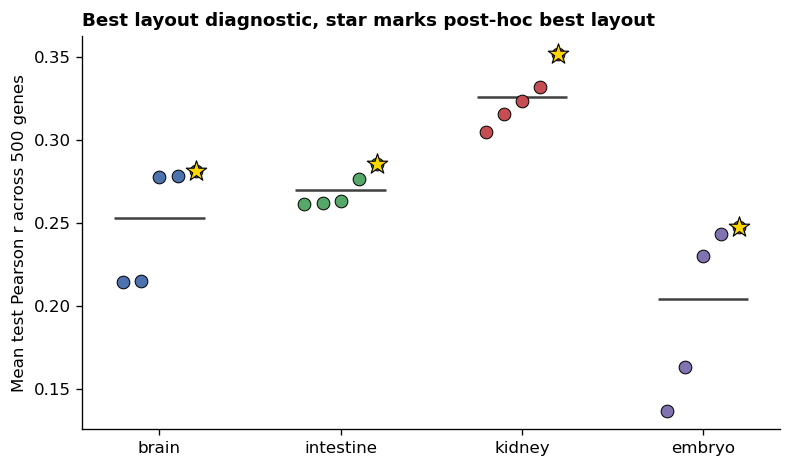

In [15]:
best = (
    per_run.sort_values(["tissue", "mean_test_r"], ascending=[True, False])
           .groupby("tissue", as_index=False)
           .first()[["tissue", "layout", "mean_test_r", "median_test_r"]]
           .rename(columns={"layout": "best_layout", "mean_test_r": "best_mean_r"})
)

worst = (
    per_run.sort_values(["tissue", "mean_test_r"], ascending=[True, True])
           .groupby("tissue", as_index=False)
           .first()[["tissue", "layout", "mean_test_r"]]
           .rename(columns={"layout": "worst_layout", "mean_test_r": "worst_mean_r"})
)

best_table = best.merge(worst, on="tissue")
best_table["range"] = best_table["best_mean_r"] - best_table["worst_mean_r"]
best_table = best_table.set_index("tissue").reindex(TISSUES).reset_index()

display(best_table.round(4))
best_table.to_csv(OUT_DIR / "best_vs_worst_layout_per_tissue.csv", index=False)

fig, ax = plt.subplots(figsize=(6.7, 4.0))
xs_base = np.arange(len(TISSUES))

for i, tissue in enumerate(TISSUES):
    sub = per_run[per_run["tissue"] == tissue].sort_values("mean_test_r")
    vals = sub["mean_test_r"].to_numpy()
    layouts = sub["layout"].to_numpy()

    if len(vals) == 0:
        continue

    xj = i + np.linspace(-0.20, 0.20, len(vals))
    ax.scatter(xj, vals, s=58, color=TISSUE_COLORS[tissue], edgecolor="black", linewidth=0.6, zorder=3)

    best_i = np.argmax(vals)
    ax.scatter(xj[best_i], vals[best_i], s=165, marker="*", color="gold", edgecolor="black", linewidth=0.7, zorder=4)

    ax.hlines(vals.mean(), i - 0.25, i + 0.25, color="black", linewidth=1.5, alpha=0.75)

ax.set_xticks(xs_base)
ax.set_xticklabels([clean_tissue_label(t) for t in TISSUES])
ax.set_ylabel("Mean test Pearson r across 500 genes")
ax.set_title("Best layout diagnostic, star marks post-hoc best layout")
plt.tight_layout()
savefig("diagnostic_best_layout_spread")
plt.show()

## 15. Per-gene predictability across layouts

In [16]:
per_gene = (
    df.groupby(["tissue", "gene_name"], dropna=False)
      .agg(
          mean_r=("test_pearson", "mean"),
          std_r=("test_pearson", lambda x: x.std(ddof=1)),
          n_layouts=("layout", "nunique"),
          mean_variance_rank=("variance_rank", "mean"),
          mean_coverage_rank=("coverage_rank", "mean"),
          mean_coverage=("coverage", "mean"),
      )
      .reset_index()
)

per_gene.to_csv(OUT_DIR / "per_gene_predictability_across_layouts.csv", index=False)

for tissue in TISSUES:
    sub = per_gene[per_gene["tissue"] == tissue].sort_values("mean_r", ascending=False)
    print(f"\n{tissue}: top 15 most consistently predictable genes")
    display(sub.head(15)[["gene_name", "mean_r", "std_r", "n_layouts", "mean_variance_rank", "mean_coverage_rank"]].round(3))


mouse_brain: top 15 most consistently predictable genes


,gene_name,mean_r,std_r,n_layouts,mean_variance_rank,mean_coverage_rank
339,Ptk2b,0.570,0.169,5,7.6,98.6
412,Slc17a7,0.541,0.196,5,42.8,153.2
425,Snhg11,0.526,0.076,5,6.2,37.4
364,Rasgrp1,0.484,0.091,5,41.4,129.6
420,Snap25,0.474,0.060,5,34.8,6.2
283,Nrgn,0.473,0.199,5,1.4,63.2
105,Cck,0.471,0.077,5,15.0,140.8
31,Apoe,0.471,0.055,5,3.8,49.0
294,Olfm1,0.459,0.193,5,4.0,26.0
282,Nptxr,0.456,0.162,5,79.2,215.4



mouse_intestine: top 15 most consistently predictable genes


,gene_name,mean_r,std_r,n_layouts,mean_variance_rank,mean_coverage_rank
1148,Apoa1,0.857,0.003,5,3.2,50.4
1143,Anpep,0.843,0.003,5,6.2,29.8
1253,Defa21,0.820,0.008,5,8.4,168.0
1287,Fabp2,0.809,0.006,5,2.6,51.0
1375,Lyz1,0.808,0.010,5,10.6,155.2
1346,Itln1,0.788,0.004,5,21.4,178.2
1141,Ang4,0.783,0.008,5,93.2,395.0
1119,AY761184,0.778,0.018,5,119.8,459.0
1484,Reg3b,0.774,0.034,5,6.6,2.0
1502,Selenop,0.761,0.005,5,8.6,49.0



mouse_kidney: top 15 most consistently predictable genes


,gene_name,mean_r,std_r,n_layouts,mean_variance_rank,mean_coverage_rank
2153,Umod,0.852,0.016,5,2.4,36.8
2068,Slc34a1,0.846,0.020,5,5.4,67.4
2057,Slc12a1,0.826,0.011,5,34.8,174.2
1842,Gpx3,0.825,0.039,5,2.6,13.8
1879,Kap,0.822,0.038,5,1.0,17.2
2067,Slc27a2,0.810,0.013,5,4.8,37.2
1671,Aldob,0.803,0.032,5,6.0,35.2
2162,Wfdc15b,0.802,0.020,5,21.8,121.4
1919,Miox,0.789,0.025,5,13.0,61.8
1686,Ass1,0.783,0.032,5,12.4,58.0



mouse_embryo: top 15 most consistently predictable genes


,gene_name,mean_r,std_r,n_layouts,mean_variance_rank,mean_coverage_rank
1037,Tnnc1,0.806,0.052,5,287.800,498.000
842,Mylpf,0.790,0.069,4,266.000,497.750
531,Acta1,0.787,0.083,3,269.667,499.333
841,Myh3,0.743,0.066,3,437.667,499.667
1042,Tpm2,0.693,0.119,5,149.200,428.800
761,Igf2,0.690,0.282,5,1.200,15.800
638,Col3a1,0.685,0.165,5,3.000,24.400
634,Col1a1,0.638,0.181,5,1.800,29.400
676,Dlk1,0.635,0.125,5,17.800,88.200
532,Acta2,0.630,0.107,2,437.500,495.500


## 16. Prediction loading helpers for spatial diagnostics

In [17]:
best_layout = dict(zip(best_table["tissue"], best_table["best_layout"]))

def get_test_predictions(tissue, layout):
    rdir = results_dir(tissue, layout)

    y_pred_path = rdir / f"test_y_pred_seed_{BASE_SEED}.npy"
    y_true_path = rdir / f"test_y_true_seed_{BASE_SEED}.npy"

    if not y_pred_path.exists() or not y_true_path.exists():
        raise FileNotFoundError(f"Missing prediction arrays in {rdir}")

    y_pred = np.load(y_pred_path)
    y_true = np.load(y_true_path)

    meta_path = PROJECT / f"cache_{tissue}" / "meta.csv"
    split_path = PROJECT / f"cache_{tissue}" / "splits" / layout / "splits.csv"

    meta = pd.read_csv(meta_path)
    splits = pd.read_csv(split_path)

    if "mmap_idx" not in meta.columns or "mmap_idx" not in splits.columns:
        raise ValueError("meta.csv and splits.csv must both contain mmap_idx.")

    meta_s = meta.merge(splits, on="mmap_idx", how="inner")

    split_col = first_existing(meta_s.columns, ["split", "set", "partition"])
    if split_col is None:
        raise ValueError(f"Could not find split column in merged metadata. Columns: {list(meta_s.columns)}")
    if split_col != "split":
        meta_s = meta_s.rename(columns={split_col: "split"})

    test_meta = meta_s[meta_s["split"] == "test"].reset_index(drop=True)

    if len(test_meta) != y_pred.shape[0]:
        raise AssertionError(f"{tissue}/{layout}: {len(test_meta)} test rows vs {y_pred.shape[0]} predictions.")

    return meta_s, test_meta, y_pred, y_true

def xy_columns(df):
    candidates = [
        ("x_centroid", "y_centroid"),
        ("center_x", "center_y"),
        ("nucleus_x", "nucleus_y"),
        ("pxl_col_in_fullres", "pxl_row_in_fullres"),
        ("array_col", "array_row"),
        ("x", "y"),
    ]
    for x_col, y_col in candidates:
        if x_col in df.columns and y_col in df.columns:
            return x_col, y_col
    raise ValueError(f"Could not infer coordinate columns. Columns: {list(df.columns)}")

def tile_column(df):
    candidates = ["tile_id", "tile", "tile_idx", "grid_tile", "tile_index", "test_tile"]
    col = first_existing(df.columns, candidates)
    if col is None:
        raise ValueError(f"Could not infer tile column. Columns: {list(df.columns)}")
    return col

def per_tile_test_r(test_meta, y_pred, y_true, min_cells=30):
    test_meta = test_meta.copy()
    test_meta["_row"] = np.arange(len(test_meta))
    tcol = tile_column(test_meta)

    rows = []
    for tid, g in test_meta.groupby(tcol):
        idx = g["_row"].to_numpy()
        if len(idx) < min_cells:
            continue

        yp = y_pred[idx]
        yt = y_true[idx]

        pm = yp - yp.mean(axis=0, keepdims=True)
        tm = yt - yt.mean(axis=0, keepdims=True)

        num = (pm * tm).sum(axis=0)
        den = np.sqrt((pm ** 2).sum(axis=0) * (tm ** 2).sum(axis=0)) + 1e-8
        r = num / den
        r = r[np.isfinite(r)]

        rows.append({
            "tile_id": tid,
            "n_cells": len(idx),
            "mean_r": float(np.mean(r)) if len(r) else np.nan,
            "median_r": float(np.median(r)) if len(r) else np.nan,
        })

    return pd.DataFrame(rows)

## 17. Spatial split visualization for best layout

This is a good supplementary figure. It makes the spatial holdout tangible and shows whether hard tiles are localized.

Do not use this as the primary evidence for model generalization, because the layout is selected post hoc.

Saved:
/hpc/group/jilab/tc459/MorphPT/experiments/gene_expression_aggregate_figures/supp_spatial_split_best_layout.png
/hpc/group/jilab/tc459/MorphPT/experiments/gene_expression_aggregate_figures/supp_spatial_split_best_layout.pdf


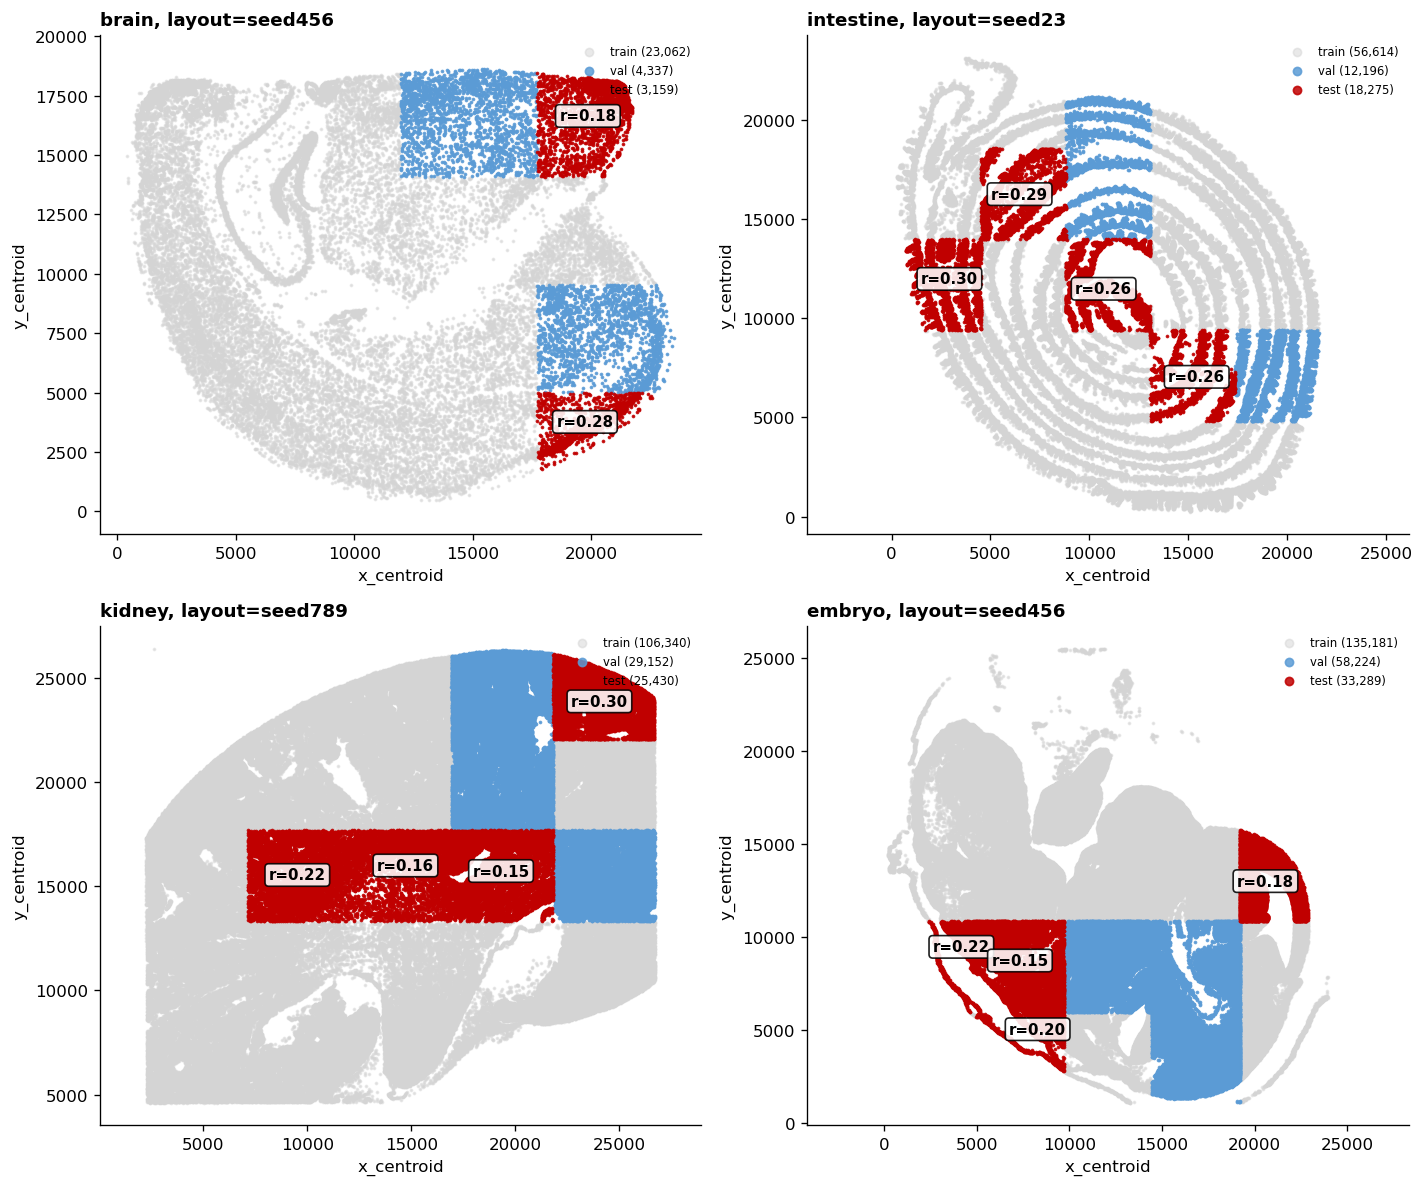

In [18]:
split_colors = {"train": "#d4d4d4", "val": "#5B9BD5", "test": "#C00000"}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, tissue in zip(axes.flat, TISSUES):
    layout = best_layout.get(tissue)

    try:
        meta_s, test_meta, y_pred, y_true = get_test_predictions(tissue, layout)
        x_col, y_col = xy_columns(meta_s)
        tcol = tile_column(meta_s)
    except Exception as e:
        ax.text(0.5, 0.5, f"{tissue}/{layout}\nmissing or incompatible\n{e}", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(clean_tissue_label(tissue))
        continue

    for spl in ["train", "val", "test"]:
        sub = meta_s[meta_s["split"] == spl]
        if sub.empty:
            continue
        ax.scatter(
            sub[x_col],
            sub[y_col],
            s=1.5,
            c=split_colors.get(spl, "gray"),
            alpha=0.50 if spl == "train" else 0.85,
            label=f"{spl} ({len(sub):,})",
        )

    tile_r = per_tile_test_r(test_meta, y_pred, y_true, min_cells=30)

    for _, t in tile_r.iterrows():
        cells = meta_s[(meta_s[tcol] == t["tile_id"]) & (meta_s["split"] == "test")]
        if cells.empty:
            continue
        cx, cy = cells[x_col].mean(), cells[y_col].mean()
        ax.annotate(
            f"r={t['mean_r']:.2f}",
            xy=(cx, cy),
            ha="center",
            va="center",
            fontsize=9,
            fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="black", alpha=0.88),
        )

    ax.set_title(f"{clean_tissue_label(tissue)}, layout={layout}")
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_aspect("equal", adjustable="datalim")
    ax.legend(loc="upper right", fontsize=7, markerscale=4)

plt.tight_layout()
savefig("supp_spatial_split_best_layout")
plt.show()

## 18. Per-tile performance distribution across all layouts

Loaded 70 per-tile evaluations across all tissue-layouts.
Saved:
/hpc/group/jilab/tc459/MorphPT/experiments/gene_expression_aggregate_figures/supp_per_tile_r_distribution.png
/hpc/group/jilab/tc459/MorphPT/experiments/gene_expression_aggregate_figures/supp_per_tile_r_distribution.pdf


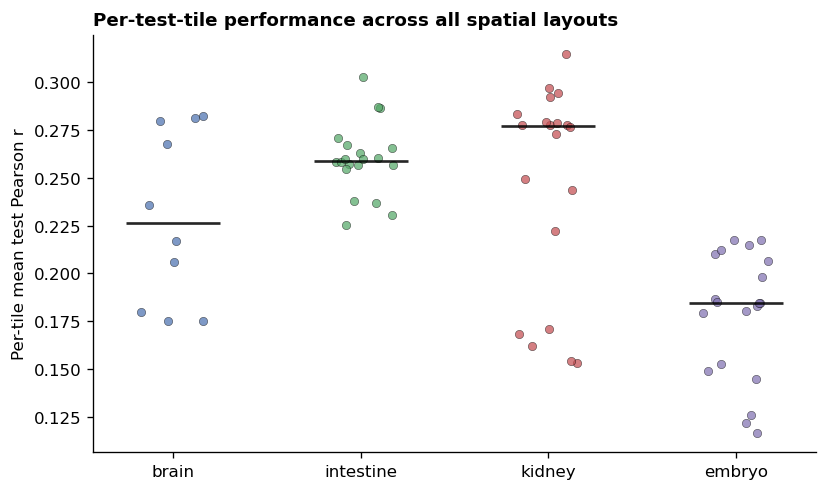

,count,mean,std,min,max
tissue,,,,,
mouse_brain,10,0.230,0.046,0.175,0.283
mouse_intestine,20,0.260,0.019,0.225,0.303
mouse_kidney,20,0.247,0.055,0.153,0.315
mouse_embryo,20,0.178,0.033,0.116,0.218


In [19]:
tile_rows = []

for tissue in TISSUES:
    for layout in LAYOUTS:
        try:
            _, test_meta, y_pred, y_true = get_test_predictions(tissue, layout)
            tdf = per_tile_test_r(test_meta, y_pred, y_true, min_cells=30)
        except Exception:
            continue

        tdf["tissue"] = tissue
        tdf["layout"] = layout
        tile_rows.append(tdf)

tile_summary = pd.concat(tile_rows, ignore_index=True) if tile_rows else pd.DataFrame()

print(f"Loaded {len(tile_summary)} per-tile evaluations across all tissue-layouts.")

if tile_summary.empty:
    print("No tile summaries available. Check whether prediction arrays and metadata exist.")
else:
    tile_summary.to_csv(OUT_DIR / "per_tile_test_r_summary_all_layouts.csv", index=False)

    fig, ax = plt.subplots(figsize=(7, 4.2))
    xs_base = np.arange(len(TISSUES))
    rng = np.random.default_rng(1)

    for i, tissue in enumerate(TISSUES):
        sub = tile_summary[tile_summary["tissue"] == tissue]
        if sub.empty:
            continue
        xj = i + rng.uniform(-0.18, 0.18, len(sub))
        ax.scatter(
            xj,
            sub["mean_r"],
            s=25,
            color=TISSUE_COLORS[tissue],
            alpha=0.72,
            edgecolor="black",
            linewidth=0.3,
        )
        ax.hlines(sub["mean_r"].median(), i - 0.25, i + 0.25, color="black", linewidth=1.6, alpha=0.85)

    ax.set_xticks(xs_base)
    ax.set_xticklabels([clean_tissue_label(t) for t in TISSUES])
    ax.set_ylabel("Per-tile mean test Pearson r")
    ax.set_title("Per-test-tile performance across all spatial layouts")
    plt.tight_layout()
    savefig("supp_per_tile_r_distribution")
    plt.show()

    display(tile_summary.groupby("tissue")["mean_r"].agg(["count", "mean", "std", "min", "max"]).reindex(TISSUES).round(3))

## Files written

In [ ]:
print("Output directory:")
print(OUT_DIR)

for p in sorted(OUT_DIR.glob("*")):
    print(p.name)

Output directory:
/hpc/group/jilab/tc459/MorphPT/experiments/gene_expression_aggregate_figures
best_vs_worst_layout_per_tissue.csv
diagnostic_best_layout_spread.pdf
diagnostic_best_layout_spread.png
mouse_gene_expression_long_results.csv
panel_a_full_500_gene_performance.pdf
panel_a_full_500_gene_performance.png
panel_b_performance_ranked_curve.pdf
panel_b_performance_ranked_curve.png
panel_c_variance_coverage_performance_tiers.pdf
panel_c_variance_coverage_performance_tiers.png
paper_composite_gene_expression_results.pdf
paper_composite_gene_expression_results.png
per_gene_predictability_across_layouts.csv
per_run_500_gene_summary.csv
per_tile_test_r_summary_all_layouts.csv
per_tissue_500_gene_pivot.csv
supp_per_cell_profile_correlation.pdf
supp_per_cell_profile_correlation.png
supp_per_tile_r_distribution.pdf
supp_per_tile_r_distribution.png
supp_spatial_split_best_layout.pdf
supp_spatial_split_best_layout.png
tier_results_aggregated.csv
tier_results_by_layout.csv
top50_variance_cove

: 